In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import datetime as dt

try:
    import snowflake.connector
except:
    ! pip install snowflake-connector-python
    import snowflake.connector

from cryptography.hazmat.backends import default_backend
from cryptography.hazmat.primitives.asymmetric import rsa, dsa
from cryptography.hazmat.primitives import serialization

In [2]:
print(f'Latest run date: {dt.datetime.today()}')

Latest run date: 2025-02-24 21:32:09.640248


#### Constants

In [3]:
str_uri = 's3://20241112-simple-model-test/08_prep_data/df.gzip'

list_cols = [
    '',
    '',
    '',
    '',
    '',
    '',
    '',
    '',
    '',
    ''
]

#### Output directory

In [4]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

#### Get data dict to map description

In [5]:
str_filename = 'data_dictionary.csv'
str_local_path = f'../../data_dictionary/{str_filename}'
df_tmp = pd.read_csv(str_local_path)
dict_map_descriptions = dict(zip(df_tmp['feature_name'], df_tmp['Description']))

#### Cnxn Snowflake

In [6]:
# # load 
# str_filename = 'datascience_rsa_key.p8'
# str_local_path = f'./{str_filename}'
# with open(str_local_path, "rb") as key:
#     p_key = serialization.load_pem_private_key(
#         key.read(),
#         password=None,
#         backend=default_backend(),
#     )
# # convert to bytes
# private_key = p_key.private_bytes(
#     encoding=serialization.Encoding.DER,
#     format=serialization.PrivateFormat.PKCS8,
#     encryption_algorithm=serialization.NoEncryption(),
# )
# # connect to snowflake
# conn = snowflake.connector.connect(
#     user='datascience', 
#     private_key=private_key,
#     account='pfs', 
#     warehouse='datascience',
#     database='raw',
#     schema='source_s3_scorehistory',
# )

In [7]:
# str_filename = 'query.sql'
# str_local_path = f'./query/{str_filename}'
# str_query = open(str_local_path, 'r').read()

In [8]:
# # pull funded
# df_funded = pd.read_sql(
#     sql=str_query,
#     con=conn,
# )

# df_funded.rename(columns={'ACCOUNT_NUMBER':'accountid',
#                          'APPLICATION_DATE':'app_date'}, inplace=True
#                 )

# df_funded = df_funded[['accountid', 'app_date']]

# # show
# df_funded

#### Group by with policy effects

In [9]:
# read in
df = pd.read_parquet(str_uri)
df

/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/fsspec/registry.py:283: UserWarning: Your installed version of s3fs is very old and known to cause
severe performance issues, see also https://github.com/dask/dask/issues/10276

To fix, you should specify a lower version bound on s3fs, or
update the current installation.

  warnings.warn(s3_msg)


,accountid,request_datetime,response_model_name,file_key,bitdebtor,bitdebtor__app,dealerstate__app,strdealershiptrackertype__app,strname__app,bitdealertrack__app,...,ENG-franchise,ENG-has_codebtor,ENG-vehicle_age,ENG-payment_to_income,ENG-loan_to_value,ENG-bk,ENG-perfect_payment_hx,ENG-perfect_payment_hx_open,ENG-perfect_payment_hx_closed,ENG-bk_x_wtd_avg
37865,5514485,2022-10-15 02:35:52.2455863,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Virginia,Independent,Virginia,False,...,0,0,5,0.111662,1.299997,0,1,1,0,0.000000
37866,5514970,2022-10-15 02:36:32.6396499,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,California,Franchise,California,False,...,1,0,6,0.055245,1.295059,0,0,0,0,0.000000
37869,5515245,2022-10-15 02:36:53.5525392,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Texas,Franchise,Texas,False,...,1,0,0,0.087712,1.156227,0,0,0,0,0.000000
37870,5515340,2022-10-15 02:37:13.5377961,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Arizona,Franchise,Arizona,False,...,1,0,5,NaN,1.599743,0,0,0,0,NaN
37871,5515580,2022-10-15 02:37:34.1144830,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,0,0,Kentucky,Franchise,Kentucky,False,...,1,1,4,NaN,1.363642,0,1,0,1,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94425,8420461,2024-11-26 02:27:09+00:00,PRESTIGE-GEN-XII,01_pull_payloads/df_requests_2024-11-25.gzip,1,1,Pennsylvania,Independent,Pennsylvania,True,...,0,0,5,NaN,1.585118,0,0,0,0,0.000000
94472,8420588,2024-11-26 06:16:16+00:00,PRESTIGE-GEN-XII,01_pull_payloads/df_requests_2024-11-25.gzip,1,1,North Carolina,Independent,North Carolina,True,...,0,0,4,NaN,1.280957,0,0,0,0,0.000000
94426,8420665,2024-11-26 02:37:11+00:00,PRESTIGE-GEN-XII,01_pull_payloads/df_requests_2024-11-25.gzip,1,1,Ohio,Franchise,Ohio,True,...,1,0,2,NaN,1.189153,1,0,0,0,0.136585
94456,8421889,2024-11-26 05:10:18+00:00,PRESTIGE-GEN-XII,01_pull_payloads/df_requests_2024-11-25.gzip,1,1,Georgia,Franchise,Georgia,True,...,1,0,0,0.206963,1.082309,0,0,0,1,0.000000


In [10]:
# cols that we care about 
list_cols = ['accountid',
    'request_datetime',
    'rp01s__tu',
    'ENG-loan_to_value',
    'g106s__tu',
    'g232s__tu',
    'ENG-wtd_avg',
]

# read in
df = pd.read_parquet(str_uri)

# subset to debtor 1
df = df[df['bitdebtor'] == 1]

# subset to cols we care about
df = df[list_cols]

# get monthly request datetime format
df['request_datetime'] = pd.to_datetime(df['request_datetime'], utc=True)
df['request_datetime'] = pd.to_datetime(df['request_datetime']).dt.strftime('%Y-%m')


# show
df

,accountid,request_datetime,rp01s__tu,ENG-loan_to_value,g106s__tu,g232s__tu,ENG-wtd_avg
37865,5514485,2022-10,0.0,1.299997,351.0,6.0,1.000000
37866,5514970,2022-10,0.0,1.295059,118.0,11.0,0.831071
37869,5515245,2022-10,0.0,1.156227,195.0,12.0,0.637931
37870,5515340,2022-10,0.0,1.599743,277.0,7.0,NaN
37872,5515580,2022-10,NaN,1.363642,204.0,12.0,NaN
...,...,...,...,...,...,...,...
94425,8420461,2024-11,1.0,1.585118,264.0,10.0,0.050000
94472,8420588,2024-11,1.0,1.280957,268.0,15.0,0.030636
94426,8420665,2024-11,0.0,1.189153,339.0,9.0,0.136585
94456,8421889,2024-11,0.0,1.082309,61.0,4.0,0.747619


#### Get cols for reposession

In [11]:
dict_map_descriptions = {key: value for key, value in dict_map_descriptions.items() if key in list_cols}
dict_map_descriptions

{'g232s__tu': 'Number of inquiries (includes duplicates)',
 'rp01s__tu': 'Number of repossession trades',
 'g106s__tu': 'Months on file'}

#### check value counts to doublecheck

In [12]:
# goup by at the account level to account for policy changes
df_tmp = df.groupby('accountid').agg({'rp01s__tu':'sum',
                                       'request_datetime':'first',
                                       'ENG-loan_to_value':'first',
                                       'g106s__tu':'mean',
                                       'g232s__tu':'max',
                                       'ENG-wtd_avg':'mean',}).reset_index()
# get monthly request datetime format
df_tmp['request_datetime'] = pd.to_datetime(df_tmp['request_datetime'], utc=True)
df_tmp['request_datetime'] = pd.to_datetime(df_tmp['request_datetime']).dt.strftime('%Y-%m')

# group by at monthly level to do over time analysis
df_apps = df_tmp.groupby('request_datetime').agg({'rp01s__tu':'mean',
                                       'ENG-loan_to_value':'mean',
                                       'g106s__tu':'mean',
                                       'g232s__tu':'mean',
                                       'ENG-wtd_avg':'mean',}).reset_index()

df_apps.head()

,request_datetime,rp01s__tu,ENG-loan_to_value,g106s__tu,g232s__tu,ENG-wtd_avg
0,2021-07,0.127168,1.269539,275.196532,12.052023,0.677593
1,2021-08,0.104348,1.285675,266.384328,12.993781,0.672760
2,2021-09,0.128183,1.283663,255.160070,12.656113,0.654657
3,2021-10,0.150583,1.273044,243.787780,12.644590,0.683431
4,2021-11,0.137351,1.252019,238.972856,12.878936,0.684232


#### plot it

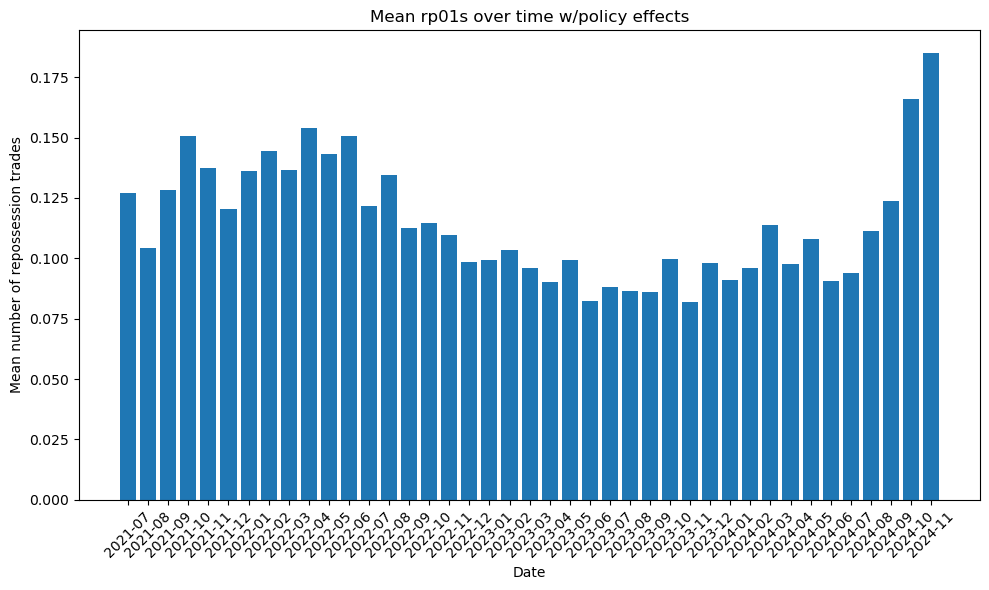

In [13]:
plt.figure(figsize=(10, 6))
plt.bar(df_apps['request_datetime'], df_apps['rp01s__tu'])

# Labeling
plt.title('Mean rp01s over time w/policy effects')
plt.xlabel('Date')
plt.ylabel('Mean number of repossession trades')

# rotate x axis 
plt.xticks(rotation=45)

# show
plt.tight_layout()
plt.show()

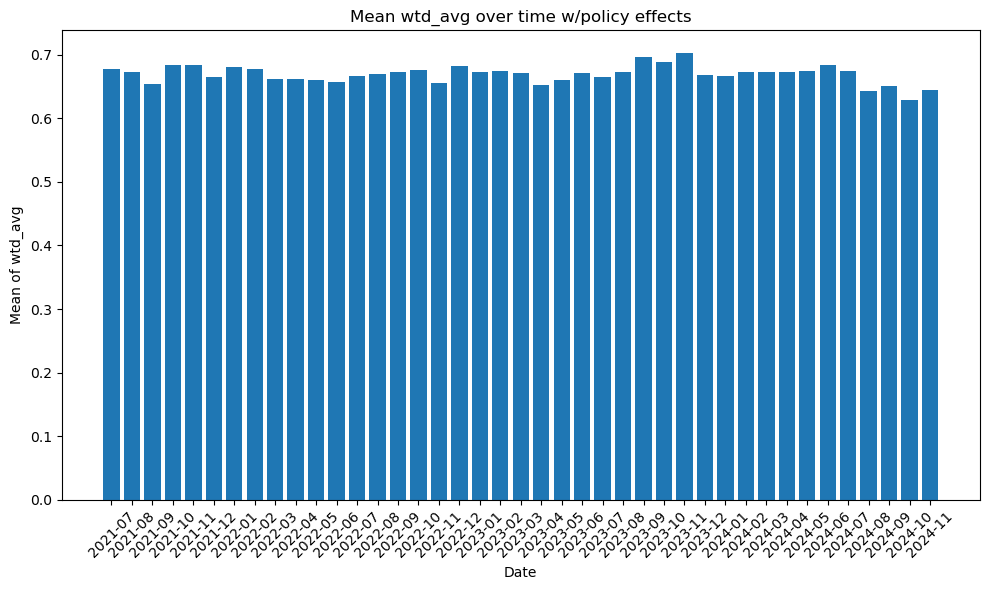

In [14]:
plt.figure(figsize=(10, 6))
plt.bar(df_apps['request_datetime'], df_apps['ENG-wtd_avg'])

# label
plt.title('Mean wtd_avg over time w/policy effects')
plt.xlabel('Date')
plt.ylabel('Mean of wtd_avg')

# rotate x axis
plt.xticks(rotation=45)

# show
plt.tight_layout()
plt.show()

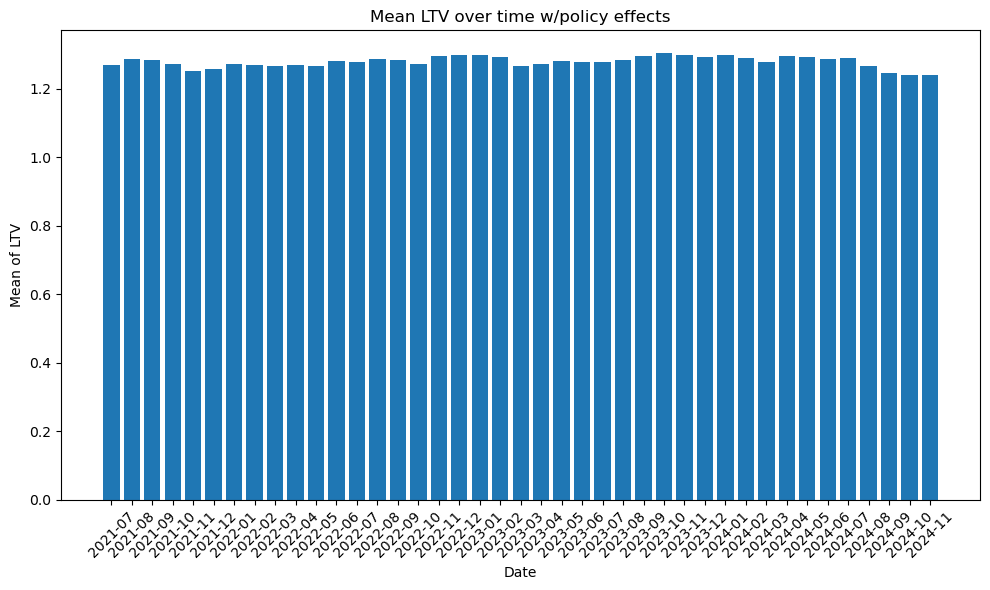

In [15]:
plt.figure(figsize=(10, 6))
plt.bar(df_apps['request_datetime'], df_apps['ENG-loan_to_value'])

# label
plt.title('Mean LTV over time w/policy effects')
plt.xlabel('Date')
plt.ylabel('Mean of LTV')

# rotate for better readability
plt.xticks(rotation=45)

# show
plt.tight_layout()
plt.show()

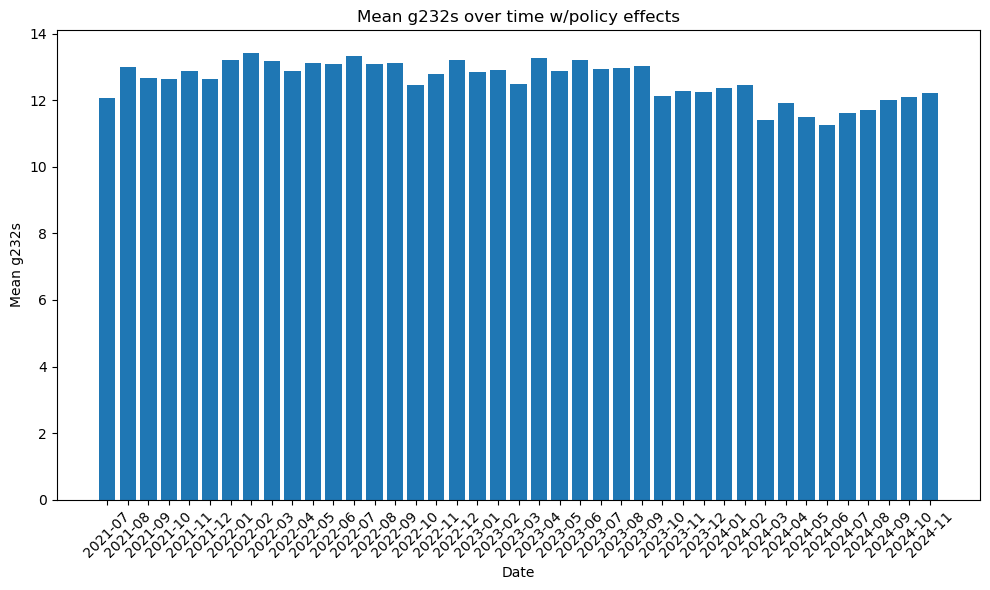

In [16]:
plt.figure(figsize=(10, 6))
plt.bar(df_apps['request_datetime'], df_apps['g232s__tu'])

# label
plt.title('Mean g232s over time w/policy effects')
plt.xlabel('Date')
plt.ylabel('Mean g232s')

# rotate x axis
plt.xticks(rotation=45)

# show
plt.tight_layout()
plt.show()

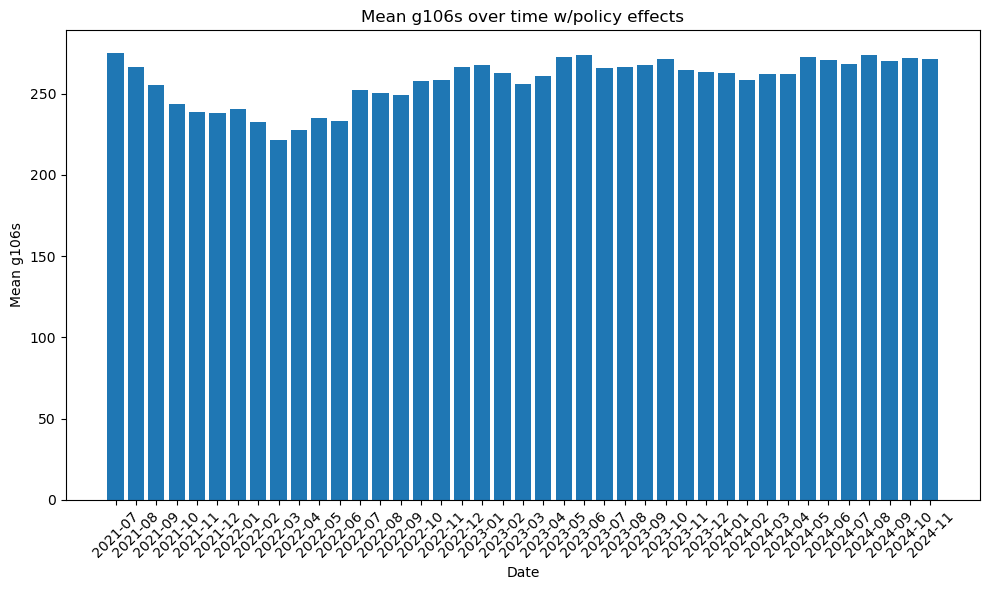

In [17]:
plt.figure(figsize=(10, 6))
plt.bar(df_apps['request_datetime'], df_apps['g106s__tu'])

# labeling
plt.title('Mean g106s over time w/policy effects')
plt.xlabel('Date')
plt.ylabel('Mean g106s')

# rotate
plt.xticks(rotation=45)

# show
plt.tight_layout()
plt.show()

#### Everything thru the door (mean for all agg account level)

In [18]:
# cols that we care about 
list_cols = ['accountid',
    'request_datetime',
    'rp01s__tu',
    'ENG-loan_to_value',
    'g106s__tu',
    'g232s__tu',
    'ENG-wtd_avg',
]

# read in
df = pd.read_parquet(str_uri)

# subset to debtor 1
# df = df[df['bitdebtor'] == 1]

# subset to cols we care about
df = df[list_cols]

# get monthly request datetime format
df['request_datetime'] = pd.to_datetime(df['request_datetime'], utc=True)
df['request_datetime'] = pd.to_datetime(df['request_datetime']).dt.strftime('%Y-%m')


# show
df

,accountid,request_datetime,rp01s__tu,ENG-loan_to_value,g106s__tu,g232s__tu,ENG-wtd_avg
37865,5514485,2022-10,0.0,1.299997,351.0,6.0,1.000000
37866,5514970,2022-10,0.0,1.295059,118.0,11.0,0.831071
37869,5515245,2022-10,0.0,1.156227,195.0,12.0,0.637931
37870,5515340,2022-10,0.0,1.599743,277.0,7.0,NaN
37871,5515580,2022-10,0.0,1.363642,160.0,4.0,1.000000
...,...,...,...,...,...,...,...
94425,8420461,2024-11,1.0,1.585118,264.0,10.0,0.050000
94472,8420588,2024-11,1.0,1.280957,268.0,15.0,0.030636
94426,8420665,2024-11,0.0,1.189153,339.0,9.0,0.136585
94456,8421889,2024-11,0.0,1.082309,61.0,4.0,0.747619


In [19]:
# group by at monthly level to do over time analysis
df_all = df.groupby('request_datetime').agg({'rp01s__tu':'mean',
                                       'ENG-loan_to_value':'mean',
                                       'g106s__tu':'mean',
                                       'g232s__tu':'mean',
                                       'ENG-wtd_avg':'mean',}).reset_index()

df_all.head()

,request_datetime,rp01s__tu,ENG-loan_to_value,g106s__tu,g232s__tu,ENG-wtd_avg
0,2021-07,0.125604,1.266793,273.397129,11.813397,0.676470
1,2021-08,0.102128,1.286163,264.505285,12.710359,0.675492
2,2021-09,0.133482,1.283833,254.712065,12.700222,0.668173
3,2021-10,0.146110,1.277655,242.181408,12.445615,0.690148
4,2021-11,0.140158,1.255855,234.374076,12.545020,0.685629


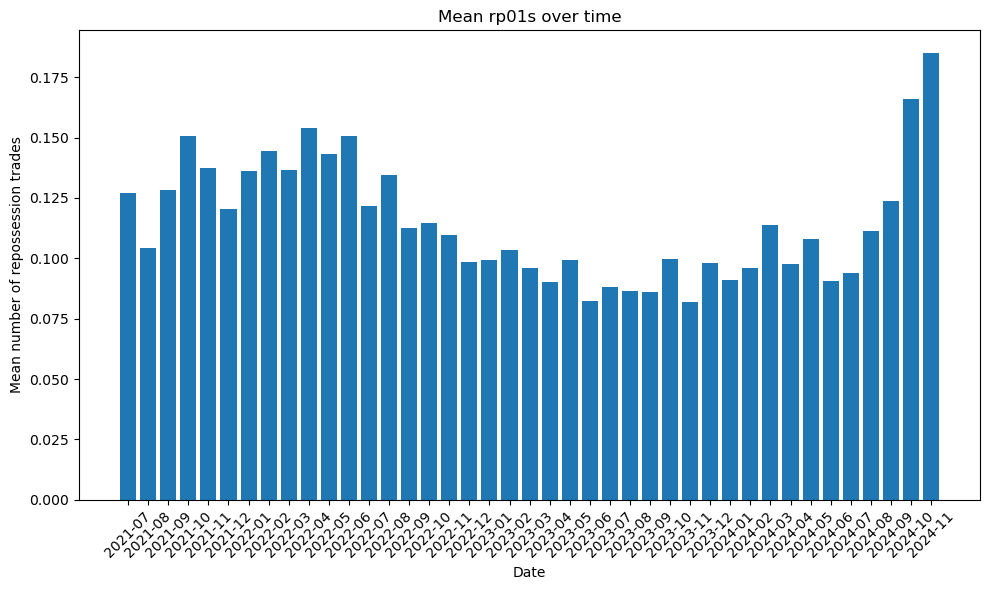

In [20]:
plt.figure(figsize=(10, 6))
plt.bar(df_apps['request_datetime'], df_apps['rp01s__tu'])

# Labeling
plt.title('Mean rp01s over time')
plt.xlabel('Date')
plt.ylabel('Mean number of repossession trades')

# rotate x axis
plt.xticks(rotation=45)

# show
plt.tight_layout()
plt.show()

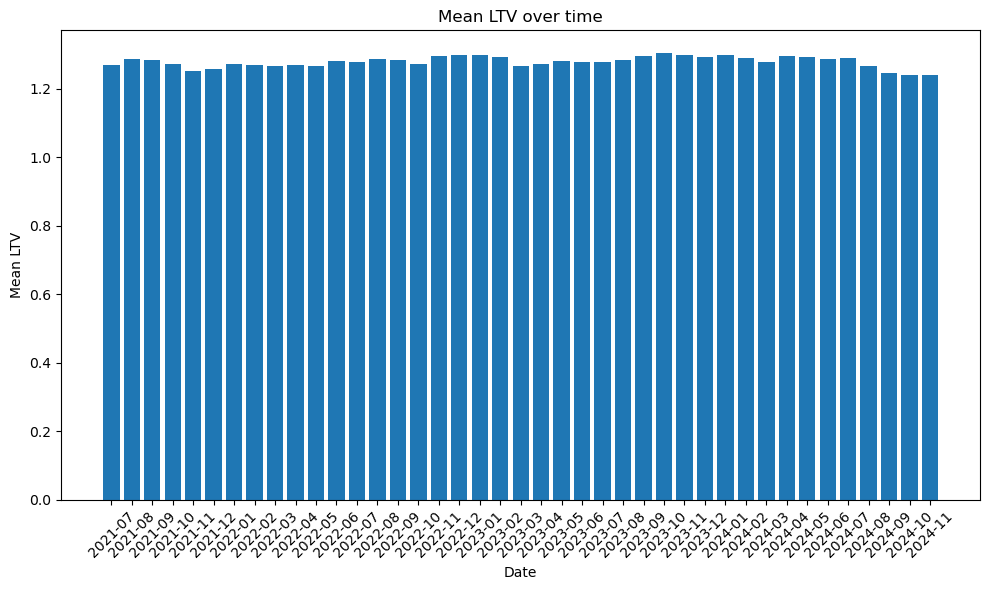

In [21]:
plt.figure(figsize=(10, 6))
plt.bar(df_apps['request_datetime'], df_apps['ENG-loan_to_value'])

# labeling the plt
plt.title('Mean LTV over time')
plt.xlabel('Date')
plt.ylabel('Mean LTV')

# rotate x axis labels
plt.xticks(rotation=45)

# show
plt.tight_layout()
plt.show()

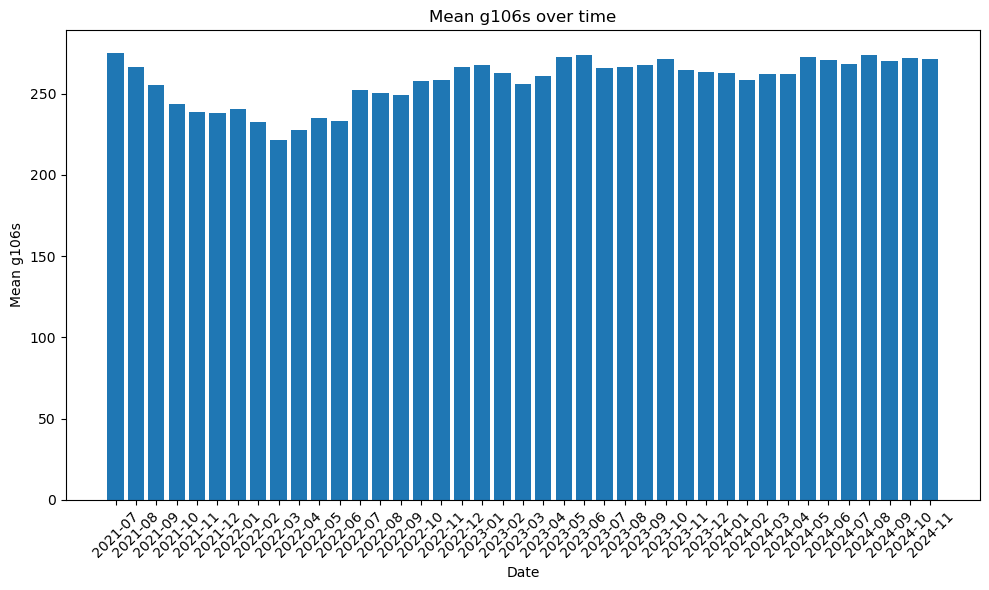

In [22]:
plt.figure(figsize=(10, 6))
plt.bar(df_apps['request_datetime'], df_apps['g106s__tu'])

# label
plt.title('Mean g106s over time')
plt.xlabel('Date')
plt.ylabel('Mean g106s')

# rotate x axis
plt.xticks(rotation=45)

# show
plt.tight_layout()
plt.show()

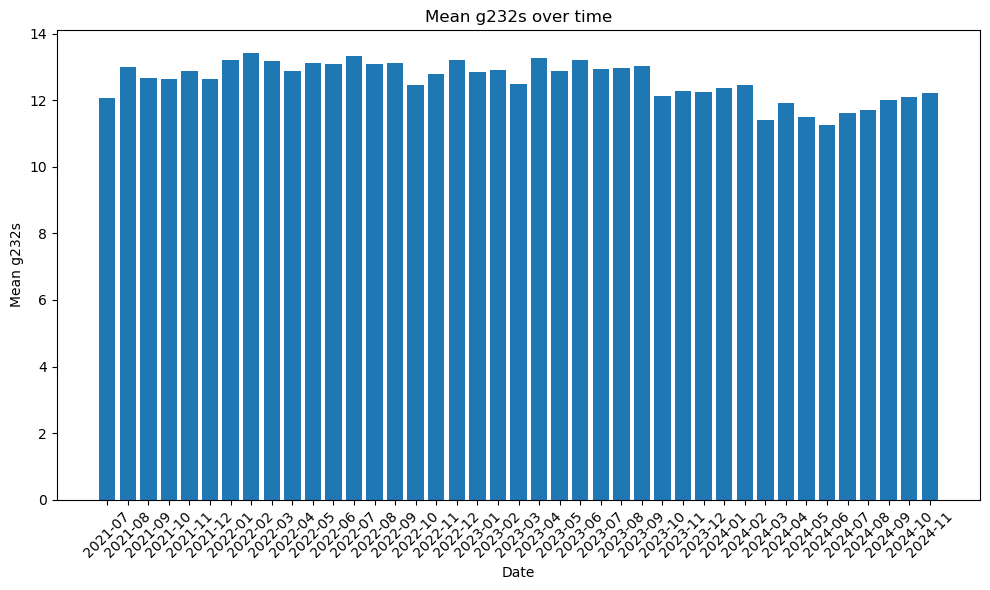

In [23]:
plt.figure(figsize=(10, 6))
plt.bar(df_apps['request_datetime'], df_apps['g232s__tu'])

# label 
plt.title('Mean g232s over time')
plt.xlabel('Date')
plt.ylabel('Mean g232s')

# rotate
plt.xticks(rotation=45)

# show plot
plt.tight_layout()
plt.show()

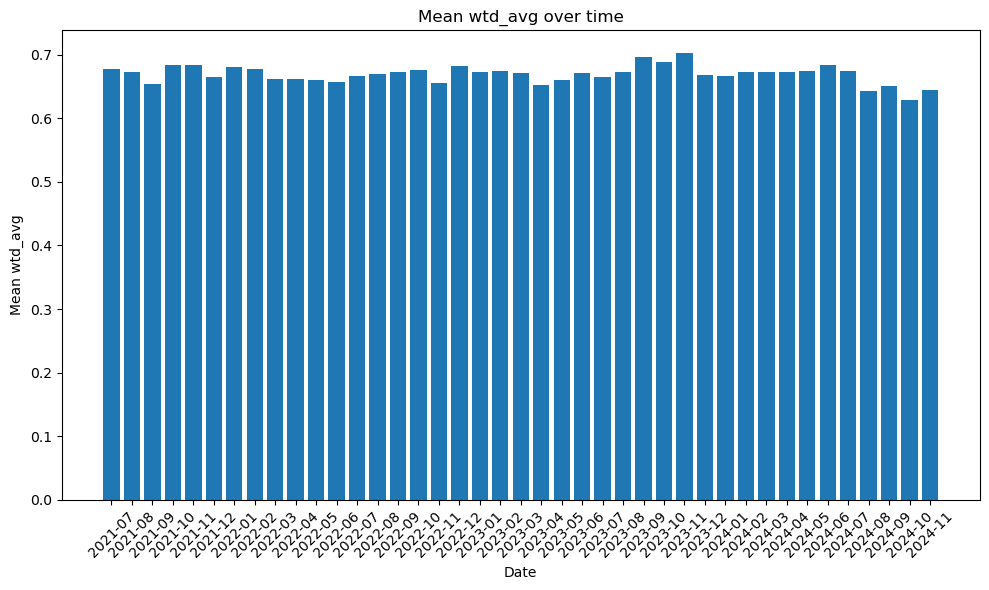

In [24]:
plt.figure(figsize=(10, 6))
plt.bar(df_apps['request_datetime'], df_apps['ENG-wtd_avg'])

# label
plt.title('Mean wtd_avg over time')
plt.xlabel('Date')
plt.ylabel('Mean wtd_avg')

# rotate x axis
plt.xticks(rotation=45)

# show the plot
plt.tight_layout()
plt.show()

#### Funded analysis

In [25]:
# # merge
# df_funded_repo = df_funded.merge(df, on='accountid', how='left')
# df_funded_repo = df_funded_repo.drop_duplicates()

# # get monthly request datetime format
# df_funded_repo['app_date'] = pd.to_datetime(df_funded_repo['app_date'], utc=True)
# df_funded_repo['app_date'] = pd.to_datetime(df_funded_repo['app_date']).dt.strftime('%Y-%m')

# # remove 3 months
# list_remove_dates = ['2021-11', 
#                      '2021-10', 
#                      '2021-09'] 

# df_funded_repo = df_funded_repo[~df_funded_repo['app_date'].isin(list_remove_dates)]

# # show
# df_funded_repo

In [26]:
# df_funds = df_funded_repo.groupby('app_date')['rp01s__tu'].mean().reset_index()
# df_funds.head()

#### plot it

In [27]:
# plt.figure(figsize=(10, 6))
# plt.bar(df_funds['app_date'], df_funds['rp01s__tu'])

# # Labeling the plot
# plt.title('Mean repos over time for all funded accounts')
# plt.xlabel('Date')
# plt.ylabel('Mean number of repossession trades')

# # Rotate x-axis labels for better readability
# plt.xticks(rotation=45)

# # Show the plot
# plt.tight_layout()
# plt.show()